In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model

In [2]:
data = pd.read_csv(
    "../data/features.csv",
    index_col=0,
    parse_dates=True
)

returns = data["Log_Return"].dropna()

returns.head()

Date
2015-10-16   -0.007358
2015-10-19    0.006195
2015-10-20    0.018093
2015-10-21   -0.000088
2015-10-22    0.015180
Name: Log_Return, dtype: float64

In [3]:
split = int(
    len(returns)*0.8
)


train = returns.iloc[:split]

test = returns.iloc[split:]

In [4]:
arima_model = ARIMA(
    train,
    order=(3,0,5)
)


arima_fit = arima_model.fit()

d:\Portfolio\Time Series Forecasting Lab\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Portfolio\Time Series Forecasting Lab\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Portfolio\Time Series Forecasting Lab\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Portfolio\Time Series Forecasting Lab\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_r

In [5]:
return_forecast = arima_fit.forecast(
    steps=len(test)
)


return_forecast.head()

d:\Portfolio\Time Series Forecasting Lab\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


2161    0.003116
2162   -0.000328
2163    0.002874
2164   -0.000005
2165    0.002082
Name: predicted_mean, dtype: float64

In [6]:
garch_model = arch_model(
    train * 100,
    vol="Garch",
    p=1,
    q=1,
    mean="Zero",
    dist="normal"
)


garch_fit = garch_model.fit(
    disp="off"
)

In [7]:
vol_forecast = garch_fit.forecast(
    horizon=len(test)
)


variance = (
    vol_forecast
    .variance
    .iloc[-1]
)


volatility_forecast = np.sqrt(
    variance
)


volatility_forecast.head()

h.001    1.556245
h.002    1.565878
h.003    1.575049
h.004    1.583782
h.005    1.592101
Name: 2024-05-17 00:00:00, dtype: float64

In [8]:
hybrid = pd.DataFrame({

    "Expected_Return":
    return_forecast.values,

    "Expected_Volatility":
    volatility_forecast.values

},
index=test.index)


hybrid.head()

,Expected_Return,Expected_Volatility
Date,,
2024-05-20,0.003116,1.556245
2024-05-21,-0.000328,1.565878
2024-05-22,0.002874,1.575049
2024-05-23,-0.000005,1.583782
2024-05-24,0.002082,1.592101


In [9]:
hybrid["Risk_Adjusted_Score"] = (
    hybrid["Expected_Return"]
    /
    (hybrid["Expected_Volatility"]/100)
)


hybrid.head()

,Expected_Return,Expected_Volatility,Risk_Adjusted_Score
Date,,,
2024-05-20,0.003116,1.556245,0.200195
2024-05-21,-0.000328,1.565878,-0.020946
2024-05-22,0.002874,1.575049,0.182471
2024-05-23,-0.000005,1.583782,-0.000324
2024-05-24,0.002082,1.592101,0.130752


In [17]:
buy_threshold = hybrid["Risk_Adjusted_Score"].quantile(0.75)

sell_threshold = hybrid["Risk_Adjusted_Score"].quantile(0.25)


def generate_signal(score):

    if score > buy_threshold:
        return "BUY"

    elif score < sell_threshold:
        return "SELL"

    else:
        return "HOLD"

In [18]:
hybrid["Signal"] = (
    hybrid["Risk_Adjusted_Score"]
    .apply(generate_signal)
)

In [19]:
hybrid["Signal"].value_counts()

Signal
HOLD    271
BUY     135
SELL    135
Name: count, dtype: int64

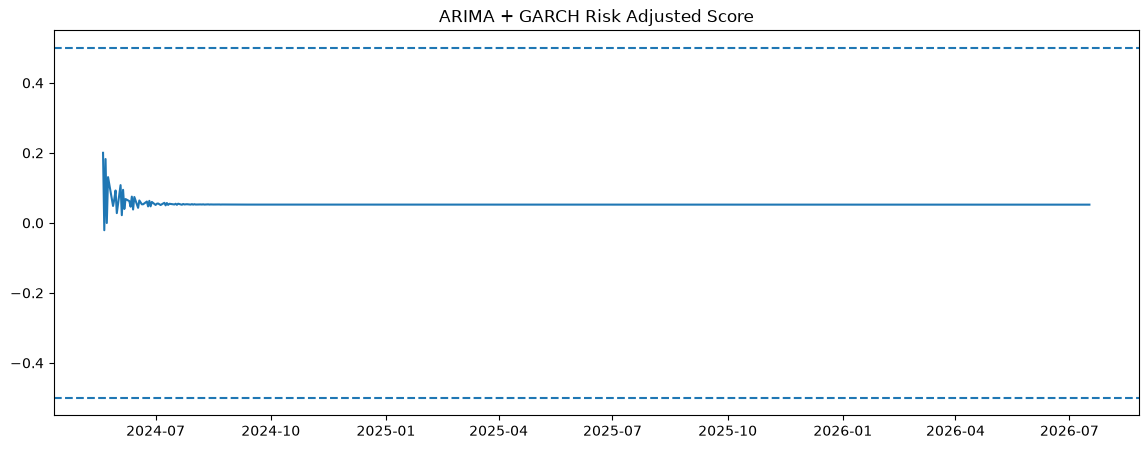

In [20]:
plt.figure(figsize=(14,5))


plt.plot(
    hybrid["Risk_Adjusted_Score"]
)


plt.axhline(
    0.5,
    linestyle="--"
)


plt.axhline(
    -0.5,
    linestyle="--"
)


plt.title(
    "ARIMA + GARCH Risk Adjusted Score"
)


plt.show()

##### BACKTESTING


In [21]:
positions = hybrid["Signal"].map({

    "BUY": 1,

    "SELL": -1,

    "HOLD": 0

})


positions.head()

Date
2024-05-20    1
2024-05-21   -1
2024-05-22    1
2024-05-23   -1
2024-05-24    1
Name: Signal, dtype: int64

In [22]:
strategy_returns = (
    positions.shift(1)
    *
    test
)


strategy_returns.head()

Date
2024-05-20         NaN
2024-05-21    0.006834
2024-05-22    0.007567
2024-05-23   -0.021283
2024-05-24   -0.016452
dtype: float64

In [23]:
strategy_cumulative = (
    1 + strategy_returns
).cumprod()


buy_hold_cumulative = (
    1 + test
).cumprod()

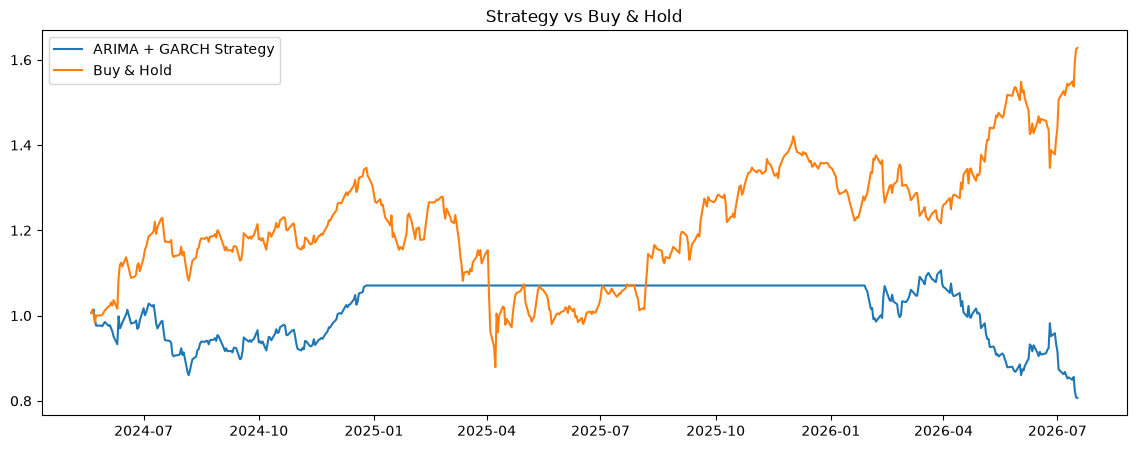

In [24]:
plt.figure(figsize=(14,5))


plt.plot(
    strategy_cumulative,
    label="ARIMA + GARCH Strategy"
)


plt.plot(
    buy_hold_cumulative,
    label="Buy & Hold"
)


plt.legend()

plt.title(
    "Strategy vs Buy & Hold"
)

plt.show()

In [25]:
def performance_metrics(returns):

    annual_return = (
        1 + returns.mean()
    )**252 - 1


    annual_vol = (
        returns.std()
        *
        np.sqrt(252)
    )


    sharpe = (
        annual_return /
        annual_vol
    )


    cumulative = (
        1 + returns
    ).cumprod()


    drawdown = (
        cumulative /
        cumulative.cummax()
        -1
    )


    max_drawdown = drawdown.min()


    return {

        "Annual Return":
            annual_return,

        "Annual Volatility":
            annual_vol,

        "Sharpe Ratio":
            sharpe,

        "Maximum Drawdown":
            max_drawdown
    }

In [26]:
strategy_results = performance_metrics(
    strategy_returns.dropna()
)


buy_hold_results = performance_metrics(
    test
)


print(
    "ARIMA + GARCH Strategy"
)

print(strategy_results)


print("\nBuy & Hold")

print(buy_hold_results)

ARIMA + GARCH Strategy
{'Annual Return': np.float64(-0.08137547079969865), 'Annual Volatility': np.float64(0.174705180939272), 'Sharpe Ratio': np.float64(-0.4657873931511223), 'Maximum Drawdown': np.float64(-0.2703889005033169)}

Buy & Hold
{'Annual Return': np.float64(0.30551894814126257), 'Annual Volatility': np.float64(0.28237761901965636), 'Sharpe Ratio': np.float64(1.0819517113358597), 'Maximum Drawdown': np.float64(-0.3471096211295861)}
